In [13]:
import sys
print (sys.executable)

/Users/riyanandi/Desktop/UKBB/myenv/bin/python


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve,precision_recall_curve, auc, roc_auc_score, precision_score, recall_score
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, make_scorer, confusion_matrix, mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, classification_report

In [15]:
training_df=pd.read_csv('training_df_3class.csv',usecols=lambda column: column != 'Unnamed: 0')
test_df=pd.read_csv('test_df_3class.csv', usecols=lambda column: column != 'Unnamed: 0')
df_HMDR=pd.read_csv("/Users/riyanandi/Desktop/HMDR/HMDR_testdata_3class_new_2.csv",index_col=0)

training_df['time_to_MN']=np.where(training_df['year_MN'].notnull(),training_df['year_MN']-training_df['year_of_assessment'],
                                   2022.0-training_df['year_of_assessment'])
test_df['time_to_MN']=np.where(test_df['year_MN'].notnull(),test_df['year_MN']-test_df['year_of_assessment'],
                               2022.0-test_df['year_of_assessment']) 

### Date of death ###

In [16]:
# Step 1: read columns eid and date of death only

cols=['eid','40000-0.0']
df_temp=pd.read_csv('/Users/riyanandi/Desktop/UKBB/ukb45304.csv',usecols=cols)

# Convert the 'date' column to datetime
df_temp['40000-0.0'] = pd.to_datetime(df_temp['40000-0.0'])
# extract the year
df_temp['date_of_death']=df_temp['40000-0.0'].dt.year+(df_temp['40000-0.0'].dt.month/12)
# drop the date column
df_temp=df_temp.drop(columns='40000-0.0')
df_temp.head()

,eid,date_of_death
0,1000010,NaN
1,1000028,NaN
2,1000034,NaN
3,1000045,NaN
4,1000052,NaN


In [17]:
df_temp['date_of_death'].notna().sum()

33393

In [18]:
# Merge with training and test set

training_df= training_df.merge(df_temp, on='eid', how='left')
test_df= test_df.merge(df_temp, on='eid', how='left')
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92316 entries, 0 to 92315
Data columns (total 43 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Broad_ID            92316 non-null  int64  
 1   gene1               5943 non-null   object 
 2   gene2               406 non-null    object 
 3   gene3               41 non-null     object 
 4   VAF1                5943 non-null   float64
 5   VAF2                406 non-null    float64
 6   VAF3                41 non-null     float64
 7   sex                 92316 non-null  int64  
 8   CH_score            92316 non-null  float64
 9   eid                 92316 non-null  float64
 10  WBC                 92316 non-null  float64
 11  RBC                 92316 non-null  float64
 12  Hbconc              92316 non-null  float64
 13  haematocrit         92316 non-null  float64
 14  MCV                 92316 non-null  float64
 15  MCHb                92316 non-null  float64
 16  MCHb

### Follow-up time calculation ###

In [19]:
import pandas as pd
from lifelines import KaplanMeierFitter

x = 2022.0

df = test_df.copy()

# Calculate follow-up time
df['followup_time'] = (
    df['date_of_death'].fillna(x) - df['year_of_assessment']
)

# Reverse KM:
# event = 1 if alive at study end (i.e., censored in standard KM)
# event = 0 if died
df['event'] = df['date_of_death'].isna().astype(int)

kmf = KaplanMeierFitter()
kmf.fit(
    durations=df['followup_time'],
    event_observed=df['event']
)

median_followup = kmf.median_survival_time_
q1 = kmf.percentile(0.75)  # Q1: 75% still "surviving" = 25th percentile of follow-up
q3 = kmf.percentile(0.25)  # Q3: 25% still "surviving" = 75th percentile of follow-up


print(f"Median follow-up time: {median_followup:.2f} years")
print(f"Q1 follow-up time: {q1:.2f} years")
print(f"Q3 follow-up time: {q3:.2f} years")

Median follow-up time: 12.92 years
Q1 follow-up time: 12.25 years
Q3 follow-up time: 13.58 years


/Users/riyanandi/Desktop/UKBB/myenv/lib/python3.9/site-packages/lifelines/fitters/__init__.py:279: ApproximationWarning: Approximating using `survival_function_`. To increase accuracy, try using or increasing the resolution of the timeline kwarg in `.fit(..., timeline=timeline)`.

  warnings.warn(
/Users/riyanandi/Desktop/UKBB/myenv/lib/python3.9/site-packages/lifelines/fitters/__init__.py:279: ApproximationWarning: Approximating using `survival_function_`. To increase accuracy, try using or increasing the resolution of the timeline kwarg in `.fit(..., timeline=timeline)`.

  warnings.warn(


In [124]:
df['followup_time'].max(),df['followup_time'].min()

(14.666666666666742, 0.08333333333325754)

In [125]:
# follow-up time 
df=df_HMDR.copy()
x=df['Date of Death'].max()

# Calculate follow-up time
df['followup_time'] = (
    df['Date of Death'].fillna(x) - df['Diagnosis Date']
)
# Reverse KM:
# event = 1 if alive at study end (i.e., censored in standard KM)
# event = 0 if died
df['event'] = df['Date of Death'].isna().astype(int)

kmf = KaplanMeierFitter()
kmf.fit(
    durations=df['followup_time'],
    event_observed=df['event']
)

median_followup = kmf.median_survival_time_

print(f"Median follow-up time: {median_followup:.2f} years")


Median follow-up time: 4.92 years


In [126]:
df['followup_time'].max(),df['followup_time'].min()

(9.916666666666742, 0.0)

In [127]:
df[df['Diagnosis Date']>=df['Date of Death']]

,Dfci.Mrn,ALLELEFRACTIONNBR,HARMONIZEDHUGOGENENM,CH,mutnum,score,Diagnosis Date,basophil,eosinophil,lymphocyte,...,sex,Pt Date Of Birth,Date of Death,MN,MN_type,MN_date,age,CHRS,followup_time,event
100,278050,0.0668,TET2,1.0,2,5.0,2022.583333,0.010,0.000,0.250,...,0,1940.333333,2022.583333,0.0,NaN,NaN,82.250000,11.5,0.0,0
173,369638,0.4941,BCORL1,0.0,0,0.0,2015.416667,0.014,0.128,0.896,...,0,1961.666667,2015.416667,0.0,NaN,NaN,53.750000,0.0,0.0,0
376,591771,0.3877,CREBBP,0.0,0,0.0,2022.250000,0.000,0.000,0.600,...,1,1965.583333,2022.250000,0.0,NaN,NaN,56.666667,0.0,0.0,0
382,594775,0.0336,DNMT3A,0.0,1,3.5,2020.083333,0.000,0.030,0.800,...,0,1948.833333,2020.083333,0.0,NaN,NaN,71.250000,11.5,0.0,0
526,654662,0.2176,TET2,1.0,3,5.0,2022.000000,0.026,0.124,2.558,...,0,1954.583333,2022.000000,0.0,NaN,NaN,67.416667,11.5,0.0,0
576,665526,0.1615,ASXL1,0.0,1,4.0,2015.416667,0.040,0.174,1.444,...,1,1937.250000,2015.416667,0.0,NaN,NaN,78.166667,9.0,0.0,0
637,680733,0.9030,TP53,1.0,1,5.5,2019.000000,0.000,0.400,1.140,...,1,1948.750000,2019.000000,0.0,NaN,NaN,70.250000,12.0,0.0,0
698,699265,0.0452,DNMT3A,0.0,1,3.5,2016.166667,0.054,0.300,1.624,...,1,1937.250000,2016.166667,0.0,NaN,NaN,78.916667,10.0,0.0,0
1005,766550,0.4816,EED,0.0,0,0.0,2017.250000,0.080,2.990,1.340,...,1,1947.250000,2017.250000,0.0,NaN,NaN,70.000000,0.0,0.0,0
1279,829786,0.7082,RUNX1,1.0,5,7.5,2018.500000,0.036,0.164,0.854,...,1,1930.666667,2018.500000,0.0,NaN,NaN,87.833333,14.0,0.0,0


### Load Model ###

In [20]:
import pickle
seed = 345

# -----------------------------------------------------------
# Load the saved model and extract parameters
# -----------------------------------------------------------
print("--- Loading Model and Extracting Parameters ---")
with open("models/3class_BRF_giantplt_ASH_latest.pkl", "rb") as f:
    loaded_package = pickle.load(f)

loaded_model = loaded_package['model']
loaded_features = loaded_package['features']
loaded_thresholds = loaded_package['optimal_thresholds']
loaded_classes = loaded_package['classes']

print("Model Features:",loaded_features)
print("Model thresholds:",loaded_thresholds)
best_params_RF = loaded_model.get_params()

--- Loading Model and Extracting Parameters ---
Model Features: ['RBC', 'Hbconc', 'MCV', 'RDW', 'platelet', 'plateletcrit', 'lymphocyte', 'monocyte', 'neutrophil', 'eosinophil', 'reticulocyte', 'age', 'giant_plt']
Model thresholds: {0.0: 0.37409706108518054, 1.0: 0.37717024984049125, 2.0: 0.309028168483651}


In [21]:
# Features used in ASH model

features=['RBC','Hbconc', 'MCV', 'RDW', 'platelet','plateletcrit','lymphocyte','monocyte', 'neutrophil', 
              'eosinophil', 'reticulocyte','age','giant_plt']

X_train=training_df[features]
y_train=training_df[['CH']]
X_test=test_df[features]
y_test=test_df[['CH']]

X_external=df_HMDR[features]
y_external=df_HMDR[['CH']]

In [22]:
class2_df=test_df.loc[test_df['CH']==2]
class1_df=test_df.loc[test_df['CH']==1]
class0_df=test_df.loc[test_df['CH']==0]

print(len(class2_df),len(class1_df),len(class0_df))

73 1219 91024


### Performance metrics table ###

In [23]:
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score, accuracy_score
)

# ------------------------------
# Define a helper function for performance metrics
# ------------------------------
def evaluate_model(model, X, y, dataset_name, classes, thresholds):
    """
    Computes AUC (per class and overall), precision, recall, and F1
    for multiclass classification with custom decision thresholds.
    """
    metrics = {"dataset": dataset_name}

    # ---- Get predicted probabilities ----
    y_pred_proba = model.predict_proba(X)
    threshold_array = np.array([thresholds[c] for c in classes])

    # ---- Apply custom thresholds to make class predictions ----
    y_pred_custom = []
    for prob_vector in y_pred_proba:
        passing_classes = np.where(prob_vector >= threshold_array)[0]
        if passing_classes.size > 0:
            # choose the class that exceeds its threshold by the largest margin
            passing_margin = prob_vector[passing_classes] - threshold_array[passing_classes]
            chosen_class_index = passing_classes[np.argmax(passing_margin)]
        else:
            # fallback: pick class with max probability
            chosen_class_index = np.argmax(prob_vector)
        y_pred_custom.append(loaded_classes[chosen_class_index])

    y_pred_custom = np.array(y_pred_custom)

    # ---- Compute AUC per class and overall ----
    n_classes = len(loaded_classes)
    auc_per_class = []
    y_true_bin = np.zeros_like(y_pred_proba)
    
    # Ensure y is a 1D array
    y = np.ravel(y)

    # create one-vs-rest binary encoding for AUC calculation
    for i, c in enumerate(loaded_classes):
        y_true_bin[:, i] = (y == c).astype(int)
        try:
            auc_c = roc_auc_score(y_true_bin[:, i], y_pred_proba[:, i])
        except ValueError:
            auc_c = np.nan
        auc_per_class.append(auc_c)

    auc_overall = np.nanmean(auc_per_class)

    # ---- Compute Precision, Recall, F1 ----
    precision = precision_score(y, y_pred_custom, labels=loaded_classes, average=None, zero_division=0)
    recall = recall_score(y, y_pred_custom, labels=loaded_classes, average=None, zero_division=0)
    f1 = f1_score(y, y_pred_custom, labels=loaded_classes, average=None, zero_division=0)

    precision_weighted = precision_score(y, y_pred_custom, average="weighted", zero_division=0)
    recall_weighted = recall_score(y, y_pred_custom, average="weighted", zero_division=0)
    f1_weighted = f1_score(y, y_pred_custom, average="weighted", zero_division=0)
    accuracy = accuracy_score(y, y_pred_custom)


    # ---- Compute PPV and NPV per class (one-vs-rest) ----
    # PPV = TP / (TP + FP)  — identical to precision, included for explicitness
    # NPV = TN / (TN + FN)
    ppv_per_class = []
    npv_per_class = []
    class_weights = []  # true positive counts, used for weighted averages

    for i, c in enumerate(loaded_classes):
        y_true_bin_c = (y == c).astype(int)
        y_pred_bin_c = (y_pred_custom == c).astype(int)

        TP = np.sum((y_true_bin_c == 1) & (y_pred_bin_c == 1))
        FP = np.sum((y_true_bin_c == 0) & (y_pred_bin_c == 1))
        TN = np.sum((y_true_bin_c == 0) & (y_pred_bin_c == 0))
        FN = np.sum((y_true_bin_c == 1) & (y_pred_bin_c == 0))

        ppv = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        npv = TN / (TN + FN) if (TN + FN) > 0 else 0.0

        ppv_per_class.append(ppv)
        npv_per_class.append(npv)
        class_weights.append(np.sum(y_true_bin_c))  # number of true instances

    ppv_per_class = np.array(ppv_per_class)
    npv_per_class = np.array(npv_per_class)
    class_weights = np.array(class_weights)

    # Weighted averages using true class counts as weights
    ppv_weighted = np.average(ppv_per_class, weights=class_weights)
    npv_weighted = np.average(npv_per_class, weights=class_weights)
    
    # ---- Store results ----
    metrics.update({
        "AUC_per_class": auc_per_class,
        "AUC_overall": auc_overall,
        "precision_per_class": precision,
        "recall_per_class": recall,
        "f1_per_class": f1,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "accuracy": accuracy,
        "ppv_per_class": ppv_per_class,
        "npv_per_class": npv_per_class,
        "ppv_weighted": ppv_weighted,
        "npv_weighted": npv_weighted,
    })

    return metrics

# ------------------------------
# Evaluate on all datasets
# ------------------------------
results = []
for X, y, name in [
    (X_train, y_train, "Training"),
    (X_test, y_test, "Test"),
    (X_external, y_external, "External")
]:
    res = evaluate_model(loaded_model, X, y, name, loaded_classes, loaded_thresholds)
    results.append(res)

# ------------------------------
# Display results
# ------------------------------
for res in results:
    print(f"\n=== {res['dataset']} Dataset ===")
    print(f"AUC overall:  {res['AUC_overall']:.3f}")
    print(f"AUC per class: {np.round(res['AUC_per_class'], 3)}")
    print(f"Precision per class: {np.round(res['precision_per_class'], 3)}")
    print(f"Recall per class:    {np.round(res['recall_per_class'], 3)}")
    print(f"F1-score per class:  {np.round(res['f1_per_class'], 3)}")
    print(f"PPV per class:       {np.round(res['ppv_per_class'], 3)}")
    print(f"NPV per class:       {np.round(res['npv_per_class'], 3)}")
    print(f"Weighted Precision:  {res['precision_weighted']:.3f}")
    print(f"Weighted Recall:     {res['recall_weighted']:.3f}")
    print(f"Weighted F1-score:   {res['f1_weighted']:.3f}")
    print(f"Weighted PPV:        {res['ppv_weighted']:.3f}")
    print(f"Weighted NPV:        {res['npv_weighted']:.3f}")
    print(f"Accuracy:           {res['accuracy']:.3f}")



=== Training Dataset ===
AUC overall:  0.742
AUC per class: [0.687 0.599 0.94 ]
Precision per class: [0.993 0.019 0.006]
Recall per class:    [0.545 0.501 0.823]
F1-score per class:  [0.704 0.037 0.011]
PPV per class:       [0.993 0.019 0.006]
NPV per class:       [0.022 0.99  1.   ]
Weighted Precision:  0.979
Weighted Recall:     0.545
Weighted F1-score:   0.694
Weighted PPV:        0.979
Weighted NPV:        0.036
Accuracy:           0.545

=== Test Dataset ===
AUC overall:  0.723
AUC per class: [0.69  0.589 0.891]
Precision per class: [0.993 0.019 0.005]
Recall per class:    [0.547 0.495 0.726]
F1-score per class:  [0.705 0.036 0.01 ]
PPV per class:       [0.993 0.019 0.005]
NPV per class:       [0.022 0.99  1.   ]
Weighted Precision:  0.979
Weighted Recall:     0.546
Weighted F1-score:   0.696
Weighted PPV:        0.979
Weighted NPV:        0.036
Accuracy:           0.546

=== External Dataset ===
AUC overall:  0.619
AUC per class: [0.754 0.365 0.739]
Precision per class: [0.968 0

In [66]:
# Get prediction
y_pred_proba=loaded_model.predict_proba(X_test)
threshold_array=np.array([loaded_thresholds[c] for c in loaded_classes])

y_pred_custom=[]

for prob_vector in y_pred_proba:
    passing_classes=np.where(prob_vector>=threshold_array)[0]
    if passing_classes.size>0:
        passing_margin=prob_vector[passing_classes]-threshold_array[passing_classes]
        max_passing_index=np.argmax(passing_margin)
        chosen_class_index=passing_classes[max_passing_index]
        chosen_class=loaded_classes[chosen_class_index]
    else:
        chosen_class_index=np.argmax(prob_vector)
        chosen_class=loaded_classes[chosen_class_index]
    
    y_pred_custom.append(chosen_class)

y_pred_custom = np.array(y_pred_custom)

#  Indices where the model predicted "CH positive with MN" (label 2)
mask_2 = (y_pred_custom == 2)
n_rows_2 = np.where(mask_2)[0]

#  Indices where the model predicted "CH positive without MN" (label 1)
mask_1 = (y_pred_custom == 1)
n_rows_1 = np.where(mask_1)[0]

#  Indices where the model predicted "Everyone else" (label 0)
mask_0 = (y_pred_custom == 0)
n_rows_0 = np.where(mask_0)[0]

# Subset of X_test corresponding to predicted positive
predicted_class2_df = test_df.iloc[n_rows_2]
predicted_class1_df = test_df.iloc[n_rows_1]
predicted_class0_df = test_df.iloc[n_rows_0]

# Print the stats 
print("Number of people predicted in class 2:",len(predicted_class2_df),len(predicted_class2_df)*100/len(y_pred_custom))
print("Number of people predicted in class 1:",len(predicted_class1_df),len(predicted_class1_df)*100/len(y_pred_custom))
print("Number of people predicted in class 0:",len(predicted_class0_df),len(predicted_class0_df)*100/len(y_pred_custom))

Number of people predicted in class 2: 10367 11.229905975128904
Number of people predicted in class 1: 31851 34.50214480696737
Number of people predicted in class 0: 50098 54.26794921790372


/var/folders/01/qxbg7rcx0ds_3w3r_82z10zh0000gn/T/ipykernel_93970/2501762953.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predicted_class0_df.loc[:,'class'] = 'Negative'
/var/folders/01/qxbg7rcx0ds_3w3r_82z10zh0000gn/T/ipykernel_93970/2501762953.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predicted_class1_df.loc[:,'class'] = 'Equivocal'
/var/folders/01/qxbg7rcx0ds_3w3r_82z10zh0000gn/T/ipykernel_93970/2501762953.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fro

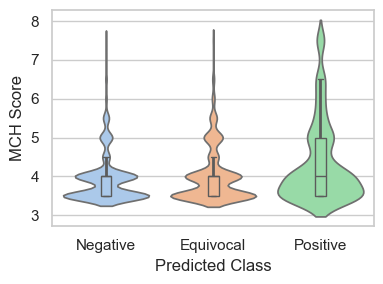

In [67]:
# Combine into one dataframe with a 'class' label
predicted_class0_df.loc[:,'class'] = 'Negative'
predicted_class1_df.loc[:,'class'] = 'Equivocal'
predicted_class2_df.loc[:,'class'] = 'Positive'

df = pd.concat([predicted_class0_df, predicted_class1_df, predicted_class2_df], ignore_index=True)

df_sel=df.loc[df['CH_score']>0]

# Set style
sns.set(style="whitegrid")

# Create violin plot
plt.figure(figsize=(4,3))
sns.violinplot(x='class', y='CH_score', data=df_sel, inner=None, palette='pastel')

# Overlay box plot to show median and IQR
sns.boxplot(x='class', y='CH_score', data=df_sel, width=0.1, showcaps=True, boxprops={'facecolor':'None'},
            showfliers=False, whiskerprops={'linewidth':2})

#plt.title('Distribution of Pre-NGS molecular CH Scores Across Predicted Classes', fontsize=14)
plt.ylabel('MCH Score', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)


plt.tight_layout()
plt.savefig("figures/MCHpredict.png", dpi=300, bbox_inches='tight')
plt.show()

### Cumulative Incidences ###

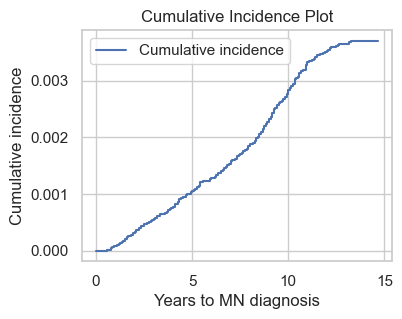

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# data
df = pd.DataFrame({'time': test_df['time_to_MN'], 'event': test_df['MN']})
df["event"] = df["event"].fillna(0)
# Drop rows with missing times (true missing data)
df = df.dropna(subset=["time"])


kmf = KaplanMeierFitter()
kmf.fit(durations=df['time'], event_observed=df['event'])

# Compute cumulative incidence
time_points = kmf.survival_function_.index
cumulative_incidence = 1 - kmf.survival_function_["KM_estimate"]

# Plot
plt.figure(figsize=(4,3))
plt.step(time_points, cumulative_incidence, where="post", label="Cumulative incidence")
plt.xlabel("Years to MN diagnosis")
plt.ylabel("Cumulative incidence")
plt.title("Cumulative Incidence Plot")
plt.legend()
plt.grid(True)
plt.show()

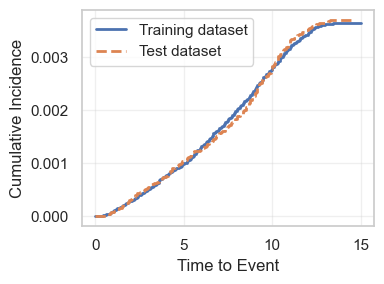

In [69]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# data
df1 = pd.DataFrame({'time': training_df['time_to_MN'], 'event': training_df['MN']})
df2 = pd.DataFrame({'time': test_df['time_to_MN'], 'event': test_df['MN']})


# Handle NaNs (discontinued → censored)
for df in [df1, df2]:
    df["event"] = df["event"].fillna(0)
    df.dropna(subset=["time"], inplace=True)

# Initialize Kaplan–Meier fitters
kmf_internal = KaplanMeierFitter()
kmf_external = KaplanMeierFitter()

# Fit survival (1 - CIF) for each
kmf_internal.fit(df1["time"], event_observed=df1["event"], label="Training dataset")
kmf_external.fit(df2["time"], event_observed=df2["event"], label="Test dataset")

# Plot cumulative incidence = 1 - survival
plt.figure(figsize=(4,3))
plt.step(
    kmf_internal.survival_function_.index,
    1 - kmf_internal.survival_function_["Training dataset"],
    where="post",
    label="Training dataset",
    linewidth=2,
)
plt.step(
    kmf_external.survival_function_.index,
    1 - kmf_external.survival_function_["Test dataset"],
    where="post",
    label="Test dataset",
    linewidth=2,
    linestyle="--",
)

# Formatting
plt.xlabel("Time to Event")
plt.ylabel("Cumulative Incidence")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### CI of MN of the predicted classes ####

In [70]:
# Compute times to MN and death
predicted_class2_df.loc[:,'t_MN']= np.where(predicted_class2_df['year_MN'].notna(),
                                      predicted_class2_df['year_MN']-predicted_class2_df['year_of_assessment'],
                                      2022.0-predicted_class2_df['year_of_assessment'])
predicted_class2_df.loc[:,'t_death']= np.where(predicted_class2_df['date_of_death'].notna(),
                                         predicted_class2_df['date_of_death']-predicted_class2_df['year_of_assessment'],
                                         2022.0-predicted_class2_df['year_of_assessment'])
predicted_class2_df.loc[:,'study_end']=2022.0-predicted_class2_df['year_of_assessment']


predicted_class1_df.loc[:,'t_MN']= np.where(predicted_class1_df['year_MN'].notna(),
                                      predicted_class1_df['year_MN']-predicted_class1_df['year_of_assessment'],
                                      2022.0-predicted_class1_df['year_of_assessment'])
predicted_class1_df.loc[:,'t_death']= np.where(predicted_class1_df['date_of_death'].notna(),
                                         predicted_class1_df['date_of_death']-predicted_class1_df['year_of_assessment'],
                                         2022.0-predicted_class1_df['year_of_assessment'])
predicted_class1_df.loc[:,'study_end']=2022.0-predicted_class1_df['year_of_assessment']


predicted_class0_df.loc[:,'t_MN']= np.where(predicted_class0_df['year_MN'].notna(),
                                      predicted_class0_df['year_MN']-predicted_class0_df['year_of_assessment'],
                                      2022.0-predicted_class0_df['year_of_assessment'])
predicted_class0_df.loc[:,'t_death']= np.where(predicted_class0_df['date_of_death'].notna(),
                                         predicted_class0_df['date_of_death']-predicted_class0_df['year_of_assessment'],
                                         2022.0-predicted_class0_df['year_of_assessment'])
predicted_class0_df.loc[:,'study_end']=2022.0-predicted_class0_df['year_of_assessment']


def calculate_time_to_event(df):
    # 1. Compute observed time
    time_observed = np.minimum.reduce([
        df['t_MN'],
        df['t_death'],
        df['study_end']
    ])
    
    # 2. Compute event indicator with censoring at death and study end
    event_observed = (
        (df['MN'] == 1) &
        (df['t_MN'] <= df['t_death']) &
        (df['t_MN'] <= df['study_end'])
    ).astype(int)

    return pd.DataFrame({
        'time': time_observed,
        'event': event_observed
    }, index=df.index)    

/var/folders/01/qxbg7rcx0ds_3w3r_82z10zh0000gn/T/ipykernel_93970/2165223536.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predicted_class2_df.loc[:,'t_MN']= np.where(predicted_class2_df['year_MN'].notna(),
/var/folders/01/qxbg7rcx0ds_3w3r_82z10zh0000gn/T/ipykernel_93970/2165223536.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predicted_class2_df.loc[:,'t_death']= np.where(predicted_class2_df['date_of_death'].notna(),
/var/folders/01/qxbg7rcx0ds_3w3r_82z10zh0000gn/T/ipykernel_93970/2165223536.py:

--- Positive CI Columns ---
['Positive Class_lower_0.95', 'Positive Class_upper_0.95']

--- Equivocal CI Columns ---
['Equivocal Class_lower_0.95', 'Equivocal Class_upper_0.95']

--- Negative CI Columns ---
['Negative Class_lower_0.95', 'Negative Class_upper_0.95']


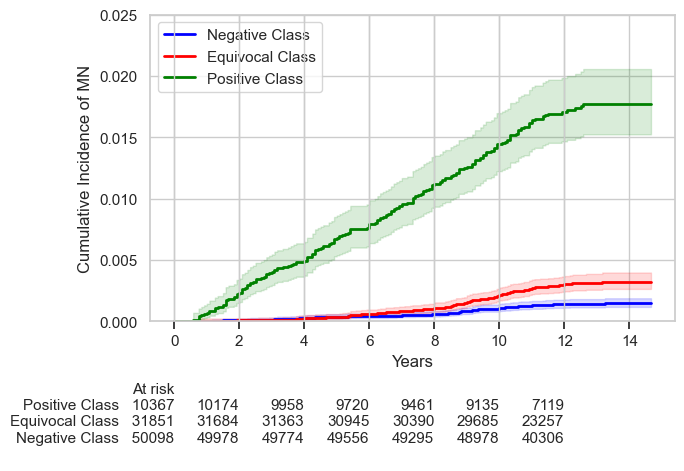

In [71]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts

# data
df1 = calculate_time_to_event(predicted_class2_df)
df2 = calculate_time_to_event(predicted_class1_df)
df3 = calculate_time_to_event(predicted_class0_df)

# Initialize Kaplan–Meier fitters
kmf_positive = KaplanMeierFitter()
kmf_equivocal = KaplanMeierFitter()
kmf_negative = KaplanMeierFitter()

# Fit survival (1 - CIF) for each
kmf_positive.fit(df1["time"], event_observed=df1["event"], label="Positive Class")
kmf_equivocal.fit(df2["time"], event_observed=df2["event"], label="Equivocal Class")
kmf_negative.fit(df3["time"], event_observed=df3["event"], label="Negative Class")

# Get confidence intervals (CI)
ci_positive = kmf_positive.confidence_interval_
ci_equivocal = kmf_equivocal.confidence_interval_
ci_negative = kmf_negative.confidence_interval_

print("--- Positive CI Columns ---")
print(ci_positive.columns.tolist())

print("\n--- Equivocal CI Columns ---")
print(ci_equivocal.columns.tolist())

print("\n--- Negative CI Columns ---")
print(ci_negative.columns.tolist())

# Plot cumulative incidence = 1 - survival
fig, ax = plt.subplots(figsize=(7,5))
# 3. Negative Dataset
label_neg = "Negative Class"
color_neg = 'blue' # Default blue color
ax.step(
    kmf_negative.survival_function_.index,
    1 - kmf_negative.survival_function_["Negative Class"],
    where="post",
    label=label_neg,
    color=color_neg,
    linewidth=2,
    #linestyle=":",
)
ax.fill_between(
    ci_negative.index,
    1 - ci_negative["Negative Class_upper_0.95"], # Lower bound of CI for 1-S(t)
    1 - ci_negative["Negative Class_lower_0.95"], # Upper bound of CI for 1-S(t)
    step="post",
    alpha=0.15,
    color=color_neg,
)

# 2. Equivocal Dataset
label_eq = "Equivocal Class"
color_eq = 'red' # Default blue color
ax.step(
    kmf_equivocal.survival_function_.index,
    1 - kmf_equivocal.survival_function_["Equivocal Class"],
    where="post",
    label=label_eq,
    color=color_eq,
    linewidth=2,
    #linestyle="--",
)
ax.fill_between(
    ci_equivocal.index,
    1 - ci_equivocal["Equivocal Class_upper_0.95"], # Lower bound of CI for 1-S(t)
    1 - ci_equivocal["Equivocal Class_lower_0.95"], # Upper bound of CI for 1-S(t)
    step="post",
    alpha=0.15,
    color=color_eq,
)

# 1. positive set
label_pos = "Positive Class"
color_pos = 'green' # Default blue color

ax.step(
    kmf_positive.survival_function_.index,
    1 - kmf_positive.survival_function_["Positive Class"],
    where="post",
    label=label_pos,
    color=color_pos,
    linewidth=2,
)
# Plot Shaded CI (1 - CI_upper and 1 - CI_lower)
# Note: Lower CI on S(t) becomes Upper CI on 1-S(t) (Cumulative Incidence)
ax.fill_between(
    ci_positive.index,
    1 - ci_positive["Positive Class_upper_0.95"], # Lower bound of CI for 1-S(t)
    1 - ci_positive["Positive Class_lower_0.95"], # Upper bound of CI for 1-S(t)
    step="post",
    alpha=0.15,
    color=color_pos,
)
# Define the x-axis times for the risk table
risk_table_times = [0, 2, 4, 6, 8, 10, 12]

# Add risk table directly below your CI plot
add_at_risk_counts(
    kmf_positive,
    kmf_equivocal,
    kmf_negative,
    ax=ax,                       # the same axis used for CI
    xticks=risk_table_times,     # align table numbers with these x-values
    rows_to_show=['At risk']     # only show number at risk
)

# Formatting
ax.set_xlabel("Years")
ax.set_ylabel("Cumulative Incidence of MN")
legend = ax.legend(loc='upper left')

ax.set_ylim(0, 0.025) # Apply y-axis restriction

plt.tight_layout()
plt.savefig("figures/CIofMN.png", dpi=300, bbox_inches='tight')
plt.savefig("figures/CIofMN.pdf", bbox_inches='tight')
plt.savefig("figures/CIofMN.svg", bbox_inches='tight')

In [24]:
from lifelines.statistics import logrank_test

durations_A=df2["time"]
durations_B=df3["time"]
event_observed_A=df2["event"]
event_observed_B=df3["event"]

results = logrank_test(durations_A, durations_B, event_observed_A, event_observed_B)
print(results.p_value)

4.923167613818366e-07


In [21]:
# survival probability at 10 years
Sp_10 = kmf_positive.predict(10)
CIp_10 = 1 - Sp_10

# get the last CI row at or before t=10
ci_p10 = ci_positive.loc[ci_positive.index <= 10].iloc[-1]

lower_p = ci_p10.iloc[0]
upper_p = ci_p10.iloc[1]

print(f"CI_positive(10) = {CIp_10:.4f} (95% CI {1-lower_p:.4f}–{1-upper_p:.4f})")
##########################################

Se_10 = kmf_equivocal.predict(10)
CIe_10 = 1 - Se_10
# get the last CI row at or before t=10
ci_e10 = ci_equivocal.loc[ci_equivocal.index <= 10].iloc[-1]

lower_e = ci_e10.iloc[0]
upper_e = ci_e10.iloc[1]

print(f"CI_equivocal(10) = {CIe_10:.4f} (95% CI {1-lower_e:.4f}–{1-upper_e:.4f})")

###########################################################
Sn_10 = kmf_negative.predict(10)
CIn_10 = 1- Sn_10
# get the last CI row at or before t=10
ci_n10 = ci_negative.loc[ci_negative.index <= 10].iloc[-1]

lower_n = ci_n10.iloc[0]
upper_n = ci_n10.iloc[1]

print(f"CI_negative(10) = {CIn_10:.4f} (95% CI {1-lower_n:.4f}–{1-upper_n:.4f})")

CI_positive(10) = 0.0144 (95% CI 0.0170–0.0122)
CI_equivocal(10) = 0.0022 (95% CI 0.0027–0.0017)
CI_negative(10) = 0.0011 (95% CI 0.0014–0.0008)


#### Censored at death ####

In [42]:
df = predicted_class2_df.copy()
len(df[df['year_MN'].notna()&df['date_of_death'].notna()&(df['year_MN']<=df['date_of_death'])])
#len(df[df['date_of_death'].notna()])

61

In [45]:
import numpy as np
import pandas as pd
from lifelines import KaplanMeierFitter, CoxPHFitter

df = predicted_class2_df.copy()

# Compute times to MN and death
t_MN= np.where(df['year_MN'].notna(),df['year_MN']-df['year_of_assessment'],2022.0-df['year_of_assessment'])
t_death= np.where(df['date_of_death'].notna(),df['date_of_death']-df['year_of_assessment'],2022.0-df['year_of_assessment'])

df['t_MN'] = t_MN
df['t_death']=t_death
# no negative follow-up times
assert (df['t_MN'] >= 0).all()
assert (df['t_death'] >= 0).all()

# look at distribution
df['t_death'].describe()

count    11055.000000
mean        12.060357
std          2.533156
min          0.000000
25%         11.750000
50%         12.666667
75%         13.416667
max         14.666667
Name: t_death, dtype: float64

<Axes: xlabel='timeline'>

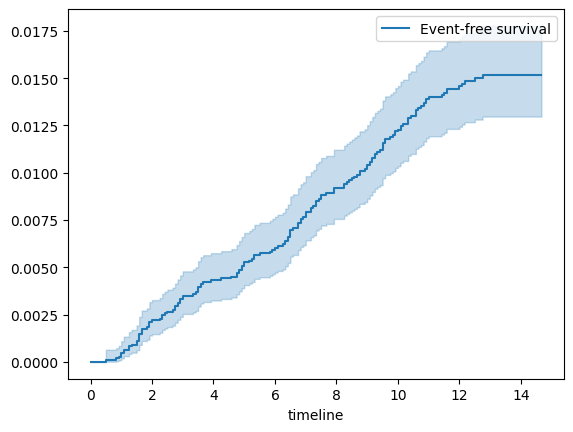

In [49]:
study_end=2022.0-df['year_of_assessment']

# 1. Compute observed time
df['time_observed'] = np.minimum.reduce([
    df['t_MN'],
    df['t_death'],
    np.full(len(df), study_end)
])


# 2. Compute event indicator with censoring at death and study end
df['event_observed'] = (
    (df['MN'] == 1) &
    (df['t_MN'] <= df['t_death']) &
    (df['t_MN'] <= study_end)
).astype(int)

#df[['time_observed','event_observed']].head()
#df['event_observed'].value_counts()

kmf = KaplanMeierFitter()

kmf.fit(
    durations=df['time_observed'],
    event_observed=df['event_observed'],
    label='Event-free survival'
)

kmf.plot_cumulative_density()

#### CI of MN of the post-NGS categories ####

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


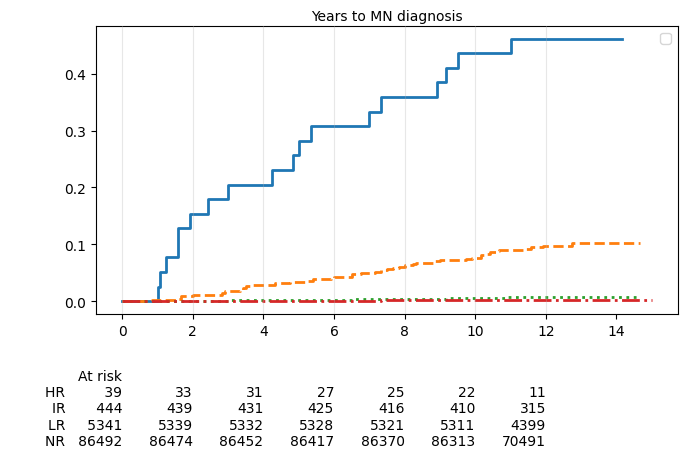

In [74]:
# 1. Actual number of high-risk individuals in the test set
hirisk = test_df.loc[test_df['CHRS'] >= 12.5]
intermediate = test_df.loc[(test_df['CHRS'] >= 10)&(test_df['CHRS'] < 12.5)]
lowrisk = test_df.loc[(test_df['CHRS'] > 0)&(test_df['CHRS'] < 10)]
norisk = test_df.loc[test_df['CHRS'] == 0]

import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts

# data
df1 = pd.DataFrame({'time': hirisk['time_to_MN'], 'event': hirisk['MN']})
df2 = pd.DataFrame({'time': intermediate['time_to_MN'], 'event': intermediate['MN']})
df3 = pd.DataFrame({'time': lowrisk['time_to_MN'], 'event': lowrisk['MN']})
df4 = pd.DataFrame({'time': norisk['time_to_MN'], 'event': norisk['MN']})


# Handle NaNs (discontinued → censored)
for df in [df1, df2, df3,df4]:
    df["time"] = df["time"].fillna(max_time)

# Initialize Kaplan–Meier fitters
kmf_hr = KaplanMeierFitter()
kmf_ir = KaplanMeierFitter()
kmf_lr = KaplanMeierFitter()
kmf_nr = KaplanMeierFitter()

# Fit survival (1 - CIF) for each
kmf_hr.fit(df1["time"], event_observed=df1["event"], label="HR")
kmf_ir.fit(df2["time"], event_observed=df2["event"], label="IR")
kmf_lr.fit(df3["time"], event_observed=df3["event"], label="LR")
kmf_nr.fit(df4["time"], event_observed=df4["event"], label="NR")

# Plot cumulative incidence = 1 - survival
fig, ax = plt.subplots(figsize=(7,5))

# 1. positive set
label_pos = "HR"
color_pos = 'C0' # Default blue color

ax.step(
    kmf_hr.survival_function_.index,
    1 - kmf_hr.survival_function_["HR"],
    where="post",
    label=label_pos,
    color=color_pos,
    linewidth=2,
)

# 2. Equivocal Dataset
label_ir = "IR"
color_ir = 'C1' # Default blue color
ax.step(
    kmf_ir.survival_function_.index,
    1 - kmf_ir.survival_function_["IR"],
    where="post",
    label=label_ir,
    color=color_ir,
    linewidth=2,
    linestyle="--",
)

# 3. Negative Dataset
label_lr = "LR"
color_lr = 'C2' # Default blue color
ax.step(
    kmf_lr.survival_function_.index,
    1 - kmf_lr.survival_function_["LR"],
    where="post",
    label=label_lr,
    color=color_lr,
    linewidth=2,
    linestyle=":",
)
# 3. Negative Dataset
label_nr = "NR"
color_nr = 'C3' # Default blue color
ax.step(
    kmf_nr.survival_function_.index,
    1 - kmf_nr.survival_function_["NR"],
    where="post",
    label=label_nr,
    color=color_nr,
    linewidth=2,
    linestyle="-.",
)

# --- ADD NUMBER AT RISK TABLE ---
# Define the time points for the table, based on your desired output
risk_table_times = [0, 2, 4, 6, 8, 10, 12]

# Call the function, passing the plot axis and the fitters
# The labels in the table will correspond to the labels used in kmf.fit()
add_at_risk_counts(kmf_hr, kmf_ir, kmf_lr, kmf_nr,
    ax=ax, 
    xticks=risk_table_times,
    rows_to_show=['At risk'] # Only show the number at risk
)
# -----------------------------------


# Formatting
plt.xlabel("Years to MN diagnosis")
plt.ylabel("Cumulative Incidence of MN")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## ICD 10 codes for ischemic CVD ##

In [34]:
Heartfail=['I255','I249','I258','I259']
Atherosclerosis=['I700','I709','I250','I251','I252']
MI=['I210','I211','I212','I213','I214','I219','I209']
Stroke=['I630','I632','I633','I634','I635','I639','I672','I638','I693']
CVD=Heartfail+Atherosclerosis+MI+Stroke
print(CVD)

['I255', 'I249', 'I258', 'I259', 'I700', 'I709', 'I250', 'I251', 'I252', 'I210', 'I211', 'I212', 'I213', 'I214', 'I219', 'I209', 'I630', 'I632', 'I633', 'I634', 'I635', 'I639', 'I672', 'I638', 'I693']


In [35]:
df_cols=pd.read_csv('/Users/riyanandi/Desktop/UKBB/ukb45304.csv',nrows=0)
col1=['eid']
columns_to_read = col1+df_cols.filter(regex='^41270|^41280').columns.to_list()

disease_df = pd.read_csv('/Users/riyanandi/Desktop/UKBB/ukb45304.csv',usecols=columns_to_read)

/var/folders/01/qxbg7rcx0ds_3w3r_82z10zh0000gn/T/ipykernel_93970/214982002.py:5: DtypeWarning: Columns (4348,4349,4350,4351,4352,4353,4354,4355,4356,4357,4358,4359,4360,4361,4362,4363,4364,4365,4366,4367,4368,4369,4370,4371,4372,4373,4374,4375,4376,4377,4378,4379,4380,4381,4382,4383,4384,4385,4386,4387,4388,4389,4390,4391,4392,4393,4394,4395,4396,4397,4398,4399,4400,4401,4402,4403,4404,4405,4406,4407,4408,4409,4410,4411,4412,4413,4414,4415,4416,4417,4418,4419,4420,4421,4422,4423,4424,4425,4426,4427,4428,4429,4430,4431,4432,4433,4434,4435,4436,4437,4438,4439,4440,4441,4442,4443,4444,4445,4446,4447,4448,4449,4450,4451,4452,4453,4454,4455,4456,4457,4458,4459,4460,4461,4462,4463,4464,4465,4466,4467,4468,4469,4470,4471,4472,4473,4474,4475,4476,4477,4478,4479,4480,4481,4482,4483,4484,4485,4486,4487,4488,4489,4490,4491,4492,4493,4494,4495,4496,4497,4498,4499,4500,4501,4502,4503,4504,4505,4506,4507,4508,4509,4510,4511,4512,4513,4514,4515,4516,4517,4518,4519,4520,4521,4522,4523,4524,4608,4609,4

In [36]:
disease_df['41280-0.0'].iloc[10]

'2020-09-09'

In [37]:
print(disease_df['41280-0.0'].dtype)

object


In [38]:
print(disease_df['41280-0.0'].head())

0    2019-05-22
1    2014-06-25
2    2014-09-22
3    2010-11-30
4    2020-09-26
Name: 41280-0.0, dtype: object


In [39]:
# Number of diagnosis columns
diagnosis=df_cols.filter(regex='^41270').columns.to_list()
print(len(diagnosis))

# Convert the date column for diagnosis
diagnosis_dates=df_cols.filter(regex='^41280').columns.to_list()

for i in diagnosis_dates:
    disease_df[i] = pd.to_datetime(disease_df[i])
    disease_df[i]=disease_df[i].dt.year+(disease_df[i].dt.month/12)
print(disease_df['41280-0.0'].iloc[10])    

213
2020.75


In [40]:
# add the year of assessment 
test_df_sel=test_df[['eid','year_of_assessment','date_of_death']]
cvd_df=pd.merge(test_df_sel,disease_df,on='eid',how='left')

diagnosis_cols = df_cols.filter(regex='^41270').columns.to_list()
diagnosis_date_cols = df_cols.filter(regex='^41280').columns.to_list()

print(len(cvd_df['eid'].unique()))
cvd_df.head()

92316


,eid,year_of_assessment,date_of_death,41270-0.0,41270-0.1,41270-0.2,41270-0.3,41270-0.4,41270-0.5,41270-0.6,...,41280-0.203,41280-0.204,41280-0.205,41280-0.206,41280-0.207,41280-0.208,41280-0.209,41280-0.210,41280-0.211,41280-0.212
0,3870203.0,2010.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5133983.0,2007.583333,NaN,E780,I48,K219,K449,M7979,N40,Z038,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5466186.0,2008.083333,NaN,G473,G479,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4302386.0,2008.250000,NaN,F171,J181,K226,L700,N62,R11,R69,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2344093.0,2008.833333,2020.833333,A099,A419,D509,D649,E109,E119,E780,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
diagnosis_codes = cvd_df[diagnosis_cols]
diagnosis_dates = cvd_df[diagnosis_date_cols].to_numpy(dtype=float)
year_of_assessment = cvd_df[['year_of_assessment']].to_numpy(dtype=float)

valid_mask = (np.isin(diagnosis_codes,CVD) &(diagnosis_dates > year_of_assessment))
#valid_mask = (diagnosis_dates > year_of_assessment)
print(np.sum(valid_mask))

19341


In [44]:

cvd_flag = valid_mask.any(axis=1).astype(int)
diagnosis_dates_valid = np.where(valid_mask, diagnosis_dates, np.nan)
earliest_dates = np.nanmin(diagnosis_dates_valid, axis=1)
earliest_dates[np.isinf(earliest_dates)] = np.nan

summary_df = pd.DataFrame({
    'eid': cvd_df['eid'],
    'year_of_assessment': cvd_df['year_of_assessment'],
    'date_of_death': cvd_df['date_of_death'],
    'CVD': cvd_flag,
    'year_CVD': earliest_dates
})

summary_df.head()

/var/folders/01/qxbg7rcx0ds_3w3r_82z10zh0000gn/T/ipykernel_93970/2855062244.py:3: RuntimeWarning: All-NaN slice encountered
  earliest_dates = np.nanmin(diagnosis_dates_valid, axis=1)


,eid,year_of_assessment,date_of_death,CVD,year_CVD
0,3870203.0,2010.250000,NaN,0,NaN
1,5133983.0,2007.583333,NaN,0,NaN
2,5466186.0,2008.083333,NaN,0,NaN
3,4302386.0,2008.250000,NaN,0,NaN
4,2344093.0,2008.833333,2020.833333,1,2017.75


In [45]:
summary_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92316 entries, 0 to 92315
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   eid                 92316 non-null  float64
 1   year_of_assessment  92316 non-null  float64
 2   date_of_death       5906 non-null   float64
 3   CVD                 92316 non-null  int64  
 4   year_CVD            9366 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 3.5 MB


In [46]:
# Subset of X_test corresponding to predicted positive
predicted_class2_df = summary_df.iloc[n_rows_2]
predicted_class1_df = summary_df.iloc[n_rows_1]
predicted_class0_df = summary_df.iloc[n_rows_0]

# Print the stats 
print("Number of people predicted in class 2:",len(predicted_class2_df),len(predicted_class2_df)*100/len(y_pred_custom))
print("Number of people predicted in class 1:",len(predicted_class1_df),len(predicted_class1_df)*100/len(y_pred_custom))
print("Number of people predicted in class 0:",len(predicted_class0_df),len(predicted_class0_df)*100/len(y_pred_custom))

Number of people predicted in class 2: 10367 11.229905975128904
Number of people predicted in class 1: 31851 34.50214480696737
Number of people predicted in class 0: 50098 54.26794921790372


In [47]:
# Compute times to MN and death
predicted_class2_df.loc[:,'t_CVD']= np.where(predicted_class2_df['year_CVD'].notna(),
                                      predicted_class2_df['year_CVD']-predicted_class2_df['year_of_assessment'],
                                      2022.0-predicted_class2_df['year_of_assessment'])
predicted_class2_df.loc[:,'t_death']= np.where(predicted_class2_df['date_of_death'].notna(),
                                         predicted_class2_df['date_of_death']-predicted_class2_df['year_of_assessment'],
                                         2022.0-predicted_class2_df['year_of_assessment'])
predicted_class2_df.loc[:,'study_end']=2022.0-predicted_class2_df['year_of_assessment']


predicted_class1_df.loc[:,'t_CVD']= np.where(predicted_class1_df['year_CVD'].notna(),
                                      predicted_class1_df['year_CVD']-predicted_class1_df['year_of_assessment'],
                                      2022.0-predicted_class1_df['year_of_assessment'])
predicted_class1_df.loc[:,'t_death']= np.where(predicted_class1_df['date_of_death'].notna(),
                                         predicted_class1_df['date_of_death']-predicted_class1_df['year_of_assessment'],
                                         2022.0-predicted_class1_df['year_of_assessment'])
predicted_class1_df.loc[:,'study_end']=2022.0-predicted_class1_df['year_of_assessment']


predicted_class0_df.loc[:,'t_CVD']= np.where(predicted_class0_df['year_CVD'].notna(),
                                      predicted_class0_df['year_CVD']-predicted_class0_df['year_of_assessment'],
                                      2022.0-predicted_class0_df['year_of_assessment'])
predicted_class0_df.loc[:,'t_death']= np.where(predicted_class0_df['date_of_death'].notna(),
                                         predicted_class0_df['date_of_death']-predicted_class0_df['year_of_assessment'],
                                         2022.0-predicted_class0_df['year_of_assessment'])
predicted_class0_df.loc[:,'study_end']=2022.0-predicted_class0_df['year_of_assessment']

/var/folders/01/qxbg7rcx0ds_3w3r_82z10zh0000gn/T/ipykernel_93970/229591883.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predicted_class2_df.loc[:,'t_CVD']= np.where(predicted_class2_df['year_CVD'].notna(),
/var/folders/01/qxbg7rcx0ds_3w3r_82z10zh0000gn/T/ipykernel_93970/229591883.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predicted_class2_df.loc[:,'t_death']= np.where(predicted_class2_df['date_of_death'].notna(),
/var/folders/01/qxbg7rcx0ds_3w3r_82z10zh0000gn/T/ipykernel_93970/229591883.py:8

In [48]:
predicted_class2_df['year_CVD'].notna().sum()

1795

### CI for CVD ###

In [49]:
def calculate_time_to_event(df):
    # 1. Compute observed time
    time_observed = np.minimum.reduce([
        df['t_CVD'],
        df['t_death'],
        df['study_end']
    ])
    
    # 2. Compute event indicator with censoring at death and study end
    event_observed = (
        (df['CVD'] == 1) &
        (df['t_CVD'] <= df['t_death']) &
        (df['t_CVD'] <= df['study_end'])
    ).astype(int)

    return pd.DataFrame({
        'time': time_observed,
        'event': event_observed
    }, index=df.index)    

--- Positive CI Columns ---
['Positive Class_lower_0.95', 'Positive Class_upper_0.95']

--- Equivocal CI Columns ---
['Equivocal Class_lower_0.95', 'Equivocal Class_upper_0.95']

--- Negative CI Columns ---
['Negative Class_lower_0.95', 'Negative Class_upper_0.95']


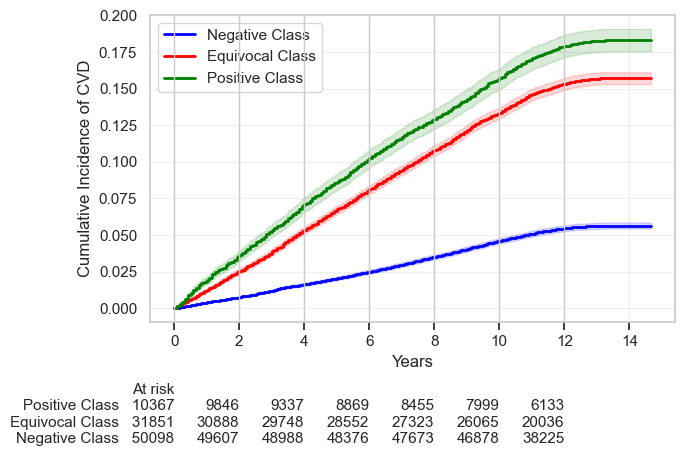

In [54]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts

# data
df1 = calculate_time_to_event(predicted_class2_df)
df2 = calculate_time_to_event(predicted_class1_df)
df3 = calculate_time_to_event(predicted_class0_df)

# Initialize Kaplan–Meier fitters
kmf_positive = KaplanMeierFitter()
kmf_equivocal = KaplanMeierFitter()
kmf_negative = KaplanMeierFitter()

# Fit survival (1 - CIF) for each
kmf_positive.fit(df1["time"], event_observed=df1["event"], label="Positive Class")
kmf_equivocal.fit(df2["time"], event_observed=df2["event"], label="Equivocal Class")
kmf_negative.fit(df3["time"], event_observed=df3["event"], label="Negative Class")

# Get confidence intervals (CI)
ci_positive = kmf_positive.confidence_interval_
ci_equivocal = kmf_equivocal.confidence_interval_
ci_negative = kmf_negative.confidence_interval_

print("--- Positive CI Columns ---")
print(ci_positive.columns.tolist())

print("\n--- Equivocal CI Columns ---")
print(ci_equivocal.columns.tolist())

print("\n--- Negative CI Columns ---")
print(ci_negative.columns.tolist())

# Plot cumulative incidence = 1 - survival
fig, ax = plt.subplots(figsize=(7,5))

# 3. Negative Dataset
label_neg = "Negative Class"
color_neg = 'blue' # Default blue color
ax.step(
    kmf_negative.survival_function_.index,
    1 - kmf_negative.survival_function_["Negative Class"],
    where="post",
    label=label_neg,
    color=color_neg,
    linewidth=2,
    #linestyle=":",
)
ax.fill_between(
    ci_negative.index,
    1 - ci_negative["Negative Class_upper_0.95"], # Lower bound of CI for 1-S(t)
    1 - ci_negative["Negative Class_lower_0.95"], # Upper bound of CI for 1-S(t)
    step="post",
    alpha=0.15,
    color=color_neg,
)

# 2. Equivocal Dataset
label_eq = "Equivocal Class"
color_eq = 'red' # Default blue color
ax.step(
    kmf_equivocal.survival_function_.index,
    1 - kmf_equivocal.survival_function_["Equivocal Class"],
    where="post",
    label=label_eq,
    color=color_eq,
    linewidth=2,
    #linestyle="--",
)
ax.fill_between(
    ci_equivocal.index,
    1 - ci_equivocal["Equivocal Class_upper_0.95"], # Lower bound of CI for 1-S(t)
    1 - ci_equivocal["Equivocal Class_lower_0.95"], # Upper bound of CI for 1-S(t)
    step="post",
    alpha=0.15,
    color=color_eq,
)

# 1. positive set
label_pos = "Positive Class"
color_pos = 'green' # Default blue color

ax.step(
    kmf_positive.survival_function_.index,
    1 - kmf_positive.survival_function_["Positive Class"],
    where="post",
    label=label_pos,
    color=color_pos,
    linewidth=2,
)
# Plot Shaded CI (1 - CI_upper and 1 - CI_lower)
# Note: Lower CI on S(t) becomes Upper CI on 1-S(t) (Cumulative Incidence)
ax.fill_between(
    ci_positive.index,
    1 - ci_positive["Positive Class_upper_0.95"], # Lower bound of CI for 1-S(t)
    1 - ci_positive["Positive Class_lower_0.95"], # Upper bound of CI for 1-S(t)
    step="post",
    alpha=0.15,
    color=color_pos,
)

# Define the x-axis times for the risk table
risk_table_times = [0, 2, 4, 6, 8, 10, 12]

# Add risk table directly below your CI plot
add_at_risk_counts(
    kmf_positive,
    kmf_equivocal,
    kmf_negative,
    ax=ax,                       # the same axis used for CI
    xticks=risk_table_times,     # align table numbers with these x-values
    rows_to_show=['At risk']     # only show number at risk
)

# Formatting
ax.set_xlabel("Years")
ax.set_ylabel("Cumulative Incidence of CVD")
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
#ax.set_ylim(0, 0.02) # Apply y-axis restriction

plt.tight_layout()
plt.savefig("figures/CIofCVD.png", dpi=300, bbox_inches='tight')
plt.savefig("figures/CIofCVD.pdf", bbox_inches='tight')
plt.savefig("figures/CIofCVD.svg", bbox_inches='tight')

In [53]:
from lifelines.statistics import logrank_test

durations_A=df1["time"]
durations_B=df3["time"]
event_observed_A=df1["event"]
event_observed_B=df3["event"]

results = logrank_test(durations_A, durations_B, event_observed_A, event_observed_B)
print(results.p_value)

0.0


In [49]:
# survival probability at 10 years
Sp_10 = kmf_positive.predict(10)
CIp_10 = 1 - Sp_10

# get the last CI row at or before t=10
ci_p10 = ci_positive.loc[ci_positive.index <= 10].iloc[-1]

lower_p = ci_p10.iloc[0]
upper_p = ci_p10.iloc[1]

print(f"CI_positive(10) = {CIp_10:.4f} (95% CI {1-lower_p:.4f}–{1-upper_p:.4f})")
##########################################

Se_10 = kmf_equivocal.predict(10)
CIe_10 = 1 - Se_10
# get the last CI row at or before t=10
ci_e10 = ci_equivocal.loc[ci_equivocal.index <= 10].iloc[-1]

lower_e = ci_e10.iloc[0]
upper_e = ci_e10.iloc[1]

print(f"CI_equivocal(10) = {CIe_10:.4f} (95% CI {1-lower_e:.4f}–{1-upper_e:.4f})")

###########################################################
Sn_10 = kmf_negative.predict(10)
CIn_10 = 1- Sn_10
# get the last CI row at or before t=10
ci_n10 = ci_negative.loc[ci_negative.index <= 10].iloc[-1]

lower_n = ci_n10.iloc[0]
upper_n = ci_n10.iloc[1]

print(f"CI_negative(10) = {CIn_10:.4f} (95% CI {1-lower_n:.4f}–{1-upper_n:.4f})")

CI_positive(10) = 0.1571 (95% CI 0.1644–0.1501)
CI_equivocal(10) = 0.1336 (95% CI 0.1375–0.1299)
CI_negative(10) = 0.0461 (95% CI 0.0480–0.0443)


## HMDR ##

In [81]:
df_HMDR.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2431 entries, 0 to 2430
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Dfci.Mrn          2431 non-null   int64  
 1   Diagnosis Date    2431 non-null   float64
 2   basophil          2431 non-null   float64
 3   eosinophil        2431 non-null   float64
 4   lymphocyte        2431 non-null   float64
 5   monocyte          2431 non-null   float64
 6   neutrophil        2431 non-null   float64
 7   MCV               2431 non-null   float64
 8   MPV               2247 non-null   float64
 9   RDW               2431 non-null   float64
 10  RBC               2431 non-null   float64
 11  Hbconc            2431 non-null   float64
 12  platelet          2431 non-null   float64
 13  MCHbconc          2431 non-null   float64
 14  giant_plt         2431 non-null   int64  
 15  plateletcrit      2431 non-null   float64
 16  reticulocyte      2431 non-null   float64
 17  

In [82]:
df_HMDR['time_to_MN']=np.where(df_HMDR['MN_type'].notnull(),df_HMDR['MN_date']-df_HMDR['Diagnosis Date'],
                               2023.0-df_HMDR['Diagnosis Date'])

In [83]:
# Get prediction
y_pred_proba=loaded_model.predict_proba(X_external)
threshold_array=np.array([loaded_thresholds[c] for c in loaded_classes])

y_pred_custom=[]

for prob_vector in y_pred_proba:
    passing_classes=np.where(prob_vector>=threshold_array)[0]
    if passing_classes.size>0:
        passing_margin=prob_vector[passing_classes]-threshold_array[passing_classes]
        max_passing_index=np.argmax(passing_margin)
        chosen_class_index=passing_classes[max_passing_index]
        chosen_class=loaded_classes[chosen_class_index]
    else:
        chosen_class_index=np.argmax(prob_vector)
        chosen_class=loaded_classes[chosen_class_index]
    
    y_pred_custom.append(chosen_class)

y_pred_custom = np.array(y_pred_custom)

#  Indices where the model predicted "CH positive with MN" (label 2)
mask_2 = (y_pred_custom == 2)
n_rows_2 = np.where(mask_2)[0]

#  Indices where the model predicted "CH positive without MN" (label 1)
mask_1 = (y_pred_custom == 1)
n_rows_1 = np.where(mask_1)[0]

#  Indices where the model predicted "Everyone else" (label 0)
mask_0 = (y_pred_custom == 0)
n_rows_0 = np.where(mask_0)[0]

# Subset of X_test corresponding to predicted positive
predicted_class2_df = df_HMDR.iloc[n_rows_2]
predicted_class1_df = df_HMDR.iloc[n_rows_1]
predicted_class0_df = df_HMDR.iloc[n_rows_0]

# Print the stats 
print("Number of people predicted in class 2:",len(predicted_class2_df),len(predicted_class2_df)*100/len(y_pred_custom))
print("Number of people predicted in class 1:",len(predicted_class1_df),len(predicted_class1_df)*100/len(y_pred_custom))
print("Number of people predicted in class 0:",len(predicted_class0_df),len(predicted_class0_df)*100/len(y_pred_custom))

Number of people predicted in class 2: 1723 70.87618264088853
Number of people predicted in class 1: 271 11.147675853558207
Number of people predicted in class 0: 437 17.97614150555327


--- Positive CI Columns ---
['Positive Class_lower_0.95', 'Positive Class_upper_0.95']

--- Equivocal CI Columns ---
['Equivocal Class_lower_0.95', 'Equivocal Class_upper_0.95']

--- Negative CI Columns ---
['Negative Class_lower_0.95', 'Negative Class_upper_0.95']


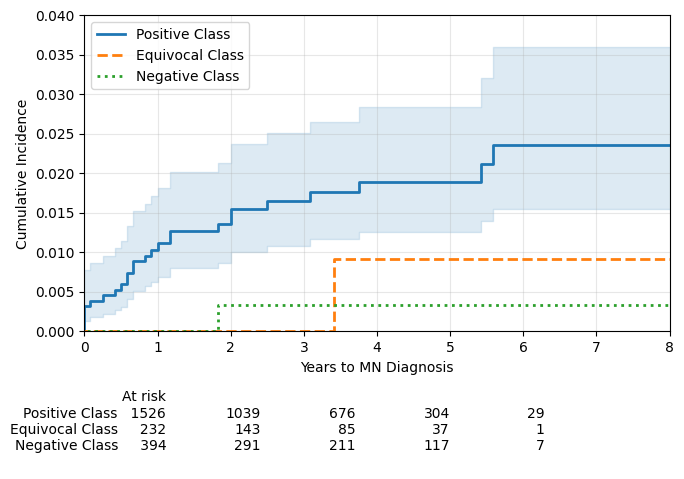

In [90]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# data
df1 = pd.DataFrame({'time': predicted_class2_df['time_to_MN'], 'event': predicted_class2_df['MN']})
df2 = pd.DataFrame({'time': predicted_class1_df['time_to_MN'], 'event': predicted_class1_df['MN']})
df3 = pd.DataFrame({'time': predicted_class0_df['time_to_MN'], 'event': predicted_class0_df['MN']})

# Initialize Kaplan–Meier fitters
kmf_positive = KaplanMeierFitter()
kmf_equivocal = KaplanMeierFitter()
kmf_negative = KaplanMeierFitter()

# Fit survival (1 - CIF) for each
kmf_positive.fit(df1["time"], event_observed=df1["event"], label="Positive Class")
kmf_equivocal.fit(df2["time"], event_observed=df2["event"], label="Equivocal Class")
kmf_negative.fit(df3["time"], event_observed=df3["event"], label="Negative Class")

# Get confidence intervals (CI)
ci_positive = kmf_positive.confidence_interval_
ci_equivocal = kmf_equivocal.confidence_interval_
ci_negative = kmf_negative.confidence_interval_

print("--- Positive CI Columns ---")
print(ci_positive.columns.tolist())

print("\n--- Equivocal CI Columns ---")
print(ci_equivocal.columns.tolist())

print("\n--- Negative CI Columns ---")
print(ci_negative.columns.tolist())

# Plot cumulative incidence = 1 - survival
fig, ax = plt.subplots(figsize=(7,5))

# 1. positive set
label_pos = "Positive Class"
color_pos = 'C0' # Default blue color

ax.step(
    kmf_positive.survival_function_.index,
    1 - kmf_positive.survival_function_["Positive Class"],
    where="post",
    label=label_pos,
    color=color_pos,
    linewidth=2,
)
# Plot Shaded CI (1 - CI_upper and 1 - CI_lower)
# Note: Lower CI on S(t) becomes Upper CI on 1-S(t) (Cumulative Incidence)
ax.fill_between(
    ci_positive.index,
    1 - ci_positive["Positive Class_upper_0.95"], # Lower bound of CI for 1-S(t)
    1 - ci_positive["Positive Class_lower_0.95"], # Upper bound of CI for 1-S(t)
    step="post",
    alpha=0.15,
    color=color_pos,
)

# 2. Equivocal Dataset
label_eq = "Equivocal Class"
color_eq = 'C1' # Default blue color
ax.step(
    kmf_equivocal.survival_function_.index,
    1 - kmf_equivocal.survival_function_["Equivocal Class"],
    where="post",
    label=label_eq,
    color=color_eq,
    linewidth=2,
    linestyle="--",
)
# 3. Negative Dataset
label_neg = "Negative Class"
color_neg = 'C2' # Default blue color
ax.step(
    kmf_negative.survival_function_.index,
    1 - kmf_negative.survival_function_["Negative Class"],
    where="post",
    label=label_neg,
    color=color_neg,
    linewidth=2,
    linestyle=":",
)


# --- ADD NUMBER AT RISK TABLE ---
# Define the time points for the table, based on your desired output
risk_table_times = [0, 2, 4, 6, 8]

# Call the function, passing the plot axis and the fitters
# The labels in the table will correspond to the labels used in kmf.fit()
add_at_risk_counts(kmf_positive, kmf_equivocal, kmf_negative,
    ax=ax, 
    xticks=risk_table_times,
    rows_to_show=['At risk'] # Only show the number at risk
)
# -----------------------------------

# Formatting
ax.set_xlabel("Years to MN Diagnosis")
ax.set_ylabel("Cumulative Incidence")
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
ax.set_ylim(0, 0.04) # Apply y-axis restriction
ax.set_xlim(0,8)

plt.tight_layout()
plt.show()
